In [6]:
import numpy as np
import matplotlib.pyplot as plt

import constants
import vertical_profile as vp
import solvers

/Users/MPRL/anaconda3/envs/alloy/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/MPRL/anaconda3/envs/alloy/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


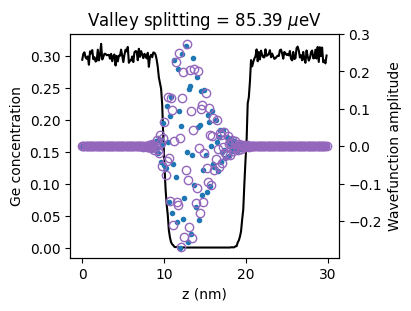

In [7]:
# Create a heterostructure profile
prof = vp.VerticalProfile(interface_type = 'sigmoid')
z_arr = prof.z_arr_nm

# Get a disordered 1D Si concentration array
a_dot_nm = 10
disordered_si = prof.generate_disordered_profile(a_dot_nm)

# Set up a 1D two-band model and solve for the lowest two eigenstates
model = solvers.TwoBand_1D(
    effective_lattice = disordered_si, 
    profile = prof, 
    vertical_field = 0.005
)

evals, evecs = model.solve(n_lowest_eigenstates=2)
v0 = evecs[:,0]
v1 = evecs[:,1]

v0 = v0 / np.sum(v0**2)**0.5
v1 = v1 / np.sum(v1**2)**0.5

ev = 1e6*model.valley_splitting()


fig, ax = plt.subplots(figsize=(4,3), layout='constrained')
ax2 = ax.twinx()
ax.plot(z_arr, 1-disordered_si, 'k-', label='Ge concentration')
ax2.plot(z_arr, v0, '.', color='tab:blue', label='Ground')
ax2.plot(z_arr, v1, 'o', markeredgecolor='tab:purple', markerfacecolor='None', label='First excited')
ax.set_xlabel('z (nm)')
ax.set_ylabel('Ge concentration')
ax2.set_ylabel('Wavefunction amplitude')

ax.set_title(rf'Valley splitting = {ev:.2f} $\mu$eV')
plt.show()





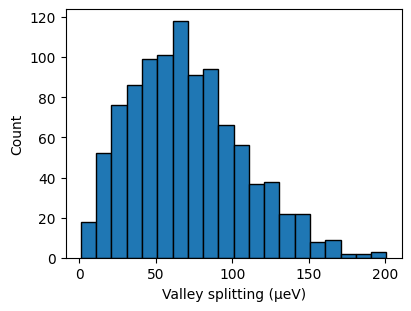

In [8]:
# Compute valley splitting for many disorder realizations and plot a histogram of the results
n_realizations = 1000
valley_splittings = np.zeros(n_realizations)
for i in range(n_realizations):
    disordered_si = prof.generate_disordered_profile(a_dot_nm)
    model = solvers.TwoBand_1D(
        effective_lattice = disordered_si, 
        profile = prof, 
        vertical_field = 0.005,
        sparse = False
    )
    valley_splittings[i] = 1e6*model.valley_splitting()


fig, ax = plt.subplots(figsize=(4,3), layout='constrained')
ax.hist(valley_splittings, bins=20, color='tab:blue', edgecolor='k')
ax.set_xlabel('Valley splitting (μeV)')
ax.set_ylabel('Count')
plt.show()